<div style="border:solid green 2px; padding: 20px">
    
<b>Привет, Михаил!</b>

Меня зовут Эдуард Григорян, я буду проводить ревью твоего проекта. 

Предлагаю общаться на «ты». Но если это не удобно — дай знать, и мы перейдем на "вы". 

Работа над проектом этой Мастерской завершена. Моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе стать отличным специалистом по Data Science, помочь тебе подготовить исследование максимально качественно, чтобы было не стыдно ссылаться на данную работу в своем резюме!

Ниже ты найдешь мои комментарии — **пожалуйста, не перемещай, не изменяй и не удаляй их**. Увидев у тебя ошибку, я лишь укажу на ее наличие. Это позволит тебе исправить ее в финальной версии проекта.  
Я буду использовать цветовую разметку:

---

<div class="alert alert-danger">
<b>Комментарий ревьюера ❌:</b>
</div>

>  Так выделены самые важные замечания. Эти замечания очень важные! Их нужно обязательно отработать, перед тем как показывать работу другим специалистам по Data Science.

---

<div class="alert alert-warning">
<b>Комментарий ревьюера ⚠️:</b>  
</div>  

> Так выделены небольшие замечания. Надеюсь, их ты тоже учтешь — твой проект от этого станет только лучше.

---

<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b>
</div>

> Так я выделяю правильные и верные действия, а так же все остальные комментарии.

---

После получения ревью работы постарайся внести изменения в исследование в соответствии с моими комментариями. Это позволит сделать твою работу еще лучше! 

<div class="alert alert-danger">
<b>Комментарий ревьюера ❌:</b>
</div>

>  Нет описания проекта! Ещё неплохо реализовать удобное переджвижение по главам проекта. 
Я показал как это сделать! Ткни на Оглавление и на название раздела, чтобы разобраться)


<div class="sc-iaZRkb kVPSsI"><h2>Описание задачи</h2>
<p>Многие знают про маркетплейсы где продаются б/у вещи, на которых есть возможность недорого купить качественную и полезную вещь. Но всегда волнует вопрос - кто и как устанавливает цену, и какие его характеристики больше всего влияют на итоговую стоимость продажи?! Вопрос становиться особо актуальным, если речь идет про дорогие товары, например про автомобили! <br>
Предлагаем вам принять участие в Мастерской, в рамках которой вы сможете поработать с данными о продажах автомобилей на вторичном рынке. Целью вашего проекта будет разработанная модель предсказания стоимости автомобиля на вторичном рынке. </p>
<h2>В ходе работы в пройдете все основные этапы полноценного исследования:</h2>
<ul>
<li>загрузка и ознакомление с данными, </li>
<li>предварительная обработка,  </li>
<li>полноценный разведочный анализ, </li>
<li>разработка новых синтетических признаков, </li>
<li>проверка на мультиколлинеарность, </li>
<li>отбор финального набора обучающих признаков, </li>
<li>выбор и обучение моделей, </li>
<li>итоговая оценка качества предсказания лучшей модели,</li>
<li>анализ важности ее признаков. </li>
</ul>
</div>

<div class="alert alert-danger">
<b>Комментарий ревьюера ❌:</b>
</div>

> Нет EDA, предобработки данных, анализа выбросов, анализа пропущенных значений, инжиниринга признаков... 
Это была важная часть работы... 


In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
import matplotlib as mtp
import seaborn as sns

In [2]:
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [3]:
data_train = pd.read_csv("./used-cars-price-prediction-19ds/train.csv")
# data_test = pd.read_csv("./used-cars-price-prediction-19ds/test.csv")

In [4]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440236 entries, 0 to 440235
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          440236 non-null  int64  
 1   make          432193 non-null  object 
 2   model         432113 non-null  object 
 3   trim          431899 non-null  object 
 4   body          429843 non-null  object 
 5   transmission  388775 non-null  object 
 6   vin           440236 non-null  object 
 7   state         440236 non-null  object 
 8   condition     430831 non-null  float64
 9   odometer      440167 non-null  float64
 10  color         439650 non-null  object 
 11  interior      439650 non-null  object 
 12  seller        440236 non-null  object 
 13  sellingprice  440236 non-null  int64  
 14  saledate      440236 non-null  object 
dtypes: float64(2), int64(2), object(11)
memory usage: 50.4+ MB


In [5]:
data_train = data_train.dropna(subset=["make", "model", "trim", "body", "transmission", "state"]).reset_index(drop=True)

In [6]:
data_train["make"].unique()

array(['Ford', 'Nissan', 'HUMMER', 'Lincoln', 'Hyundai', 'Buick',
       'Chevrolet', 'Honda', 'Acura', 'Cadillac', 'GMC', 'Saab', 'Dodge',
       'Toyota', 'Volkswagen', 'BMW', 'Infiniti', 'Chrysler', 'Kia',
       'Jaguar', 'Subaru', 'Jeep', 'Lexus', 'Scion', 'FIAT', 'Suzuki',
       'Mercedes-Benz', 'Mazda', 'Volvo', 'Audi', 'MINI', 'Isuzu',
       'Mitsubishi', 'smart', 'Pontiac', 'Porsche', 'Land Rover',
       'Saturn', 'Ram', 'Oldsmobile', 'Mercury', 'Bentley', 'Fisker',
       'Maserati', 'Tesla', 'Rolls-Royce', 'Plymouth', 'Ferrari',
       'Lamborghini', 'Geo', 'Aston Martin', 'Daewoo'], dtype=object)

In [7]:
data_train["model"].unique()

array(['Edge', 'Fusion', 'Sentra', 'H2', 'MKZ', 'Escape', 'Elantra',
       'Freestyle', 'Lucerne', 'Windstar', 'Murano', 'Equinox', 'Accord',
       'Silverado 1500', 'Civic', 'MDX', 'CTS', 'Taurus', 'SRX', 'Yukon',
       '9-3', 'Explorer', 'F-150', 'Charger', 'Armada', 'Avalon', 'Tahoe',
       'Malibu', 'Passat', 'Camry', 'Flex', '3 Series', 'Q50', 'Altima',
       '300', 'Sonata', 'Envoy XL', 'Rogue', 'Accent', 'Maxima', 'Forte',
       'XF', 'Outback', 'Grand Caravan', 'Cherokee', 'Impala', 'Optima',
       'Expedition', 'IS 250', '200', 'Veloster', 'Golf', 'RAV4',
       'Five Hundred', 'G Coupe', 'Grand Cherokee', 'X-Type',
       'G Convertible', 'Tacoma', 'xA', 'G Sedan', 'TL', 'Soul', '500L',
       'Town and Country', 'Mustang', 'HHR', 'Reno', 'Suburban',
       'PT Cruiser', 'GX 460', 'Sienna', 'SL-Class', 'Envoy', 'Patriot',
       'Versa', 'Aspen', 'M', 'Colorado', 'Beetle', 'Spark', 'RX 330',
       'Rendezvous', 'Town Car', '1 Series', 'Venture', 'Corolla',
       'Foc

In [8]:
data_train["trim"].unique()

array(['SEL', 'SE', '2.0 SL', ..., '2.5 X L.L.Bean Edition',
       '3500 High Roof 140 WB', 'Rocky Mountain'], dtype=object)

In [9]:
data_train["body"].unique()

array(['suv', 'Sedan', 'sedan', 'SUV', 'wagon', 'Minivan', 'Regular Cab',
       'Coupe', 'SuperCrew', 'Wagon', 'Extended Cab', 'convertible',
       'SuperCab', 'Hatchback', 'minivan', 'hatchback', 'G Coupe',
       'G Convertible', 'coupe', 'Access Cab', 'G Sedan', 'regular cab',
       'Convertible', 'supercrew', 'Quad Cab', 'tsx sport wagon',
       'Crew Cab', 'Van', 'g sedan', 'CTS Coupe', 'E-Series Van', 'Koup',
       'King Cab', 'extended cab', 'koup', 'access cab', 'Double Cab',
       'double cab', 'crew cab', 'quad cab', 'g coupe', 'CrewMax Cab',
       'supercab', 'g convertible', 'Genesis Coupe', 'van',
       'e-series van', 'G37 Coupe', 'club cab', 'Beetle Convertible',
       'Mega Cab', 'regular-cab', 'Xtracab', 'cts coupe', 'Club Cab',
       'q60 coupe', 'mega cab', 'Elantra Coupe', 'crewmax cab',
       'Promaster Cargo Van', 'king cab', 'TSX Sport Wagon', 'CTS Wagon',
       'Cab Plus 4', 'G37 Convertible', 'genesis coupe', 'Transit Van',
       'Q60 Convertible',

In [10]:
data_train["transmission"].unique()

array(['automatic', 'manual'], dtype=object)

In [11]:
data_train["state"].unique()

array(['md', 'mo', 'nj', 'tx', 'mi', 'fl', 'oh', 'az', 'ca', 'ga', 'tn',
       'in', 'pa', 'nc', 'wi', 'co', 'ny', 'il', 'nv', 'mn', 'va', 'wa',
       'sc', 'la', 'ne', 'ok', 'or', 'ma', 'pr', 'hi', 'ut', 'ms', 'nm',
       'al'], dtype=object)

In [12]:
data_train["color"].unique() # '—' = nan

array(['black', 'gold', 'blue', 'white', 'gray', '—', 'silver', 'red',
       'brown', 'green', 'beige', nan, 'off-white', 'yellow', 'burgundy',
       'orange', 'purple', 'turquoise', 'charcoal', 'lime', 'pink'],
      dtype=object)

In [13]:
data_train["interior"].unique() # '—' = nan

array(['black', 'beige', 'gray', 'tan', '—', nan, 'blue', 'brown',
       'white', 'silver', 'red', 'green', 'gold', 'purple', 'orange',
       'off-white', 'burgundy', 'yellow'], dtype=object)

In [14]:
RANDOM_STATE = 12345

CATIGORIES_TRIM = ["base", "extra level touring", "limited", "luxury touring", "level extra", "standard level extra", "standard level touring", "classic edition", "custom edition",
              "deluxe", "deluxe level", "extra", "grand touring", "luxury","luxury edition", "luxury sport", "luxury special", "luxury touring", "sport edition", 
              "special edition", "special equipment","standart level", "standart", "special version", "touring", 
              "xlt", "ltd", "ltz", "gle", "sle", "slt", "ce",  "dx",  "dl",  "ex",  "gl",  "gt", "lx",  "le", "sl", "sv",  "ls", "lt",  "se",]

CATIGORIES_COLUMNS = ["make", "model", "trim", "body", "transmission", "state", "color", "interior"]

In [15]:
def make_unique(data):
    if "ford" in data:
        return "ford"
    if "gmc" in data:
        return "gmc"
    if "land" in data:
        return "landrover"
    if "mercedes" in data:
        return "mercedes"
    if data == "vw":
        return "volkswagen"
    if "dodge" in data:
        return "dodge"
    if "mazda" in data:
        return "mazda"
    else:
        return data

In [16]:
def body_unique(data):
    if data.find("cab") != -1 or data == "koup":
        return "pick-up"
    if data.find("convertible") != -1:
        return "convertible"
    if data.find("coupe") != -1:
        return "coupe"
    if data.find("wagon") != -1:
        return "wagon"
    if data.find("van") != -1:
        return "van"
    if data.find("sedan") != -1:
        return "sedan"
    if data.find("van") != -1:
        return "van"
    else:
        return data

In [17]:
def trim_unique(data):

    def classify_trim_levels(trim_levels, category):
        for trim_level in trim_levels:
            if trim_level in category:
                return trim_level
        return "unknown"

    trim = classify_trim_levels(CATIGORIES_COLUMNS, data)
    if trim == "extra level touring":
        return "xlt"
    if trim == "limited":
        return "ltd"
    if trim == "luxury touring":
        return "ltz"
    if trim == "level extra":
        return "gle"
    if trim == "standard level extra":
        return "sle"
    if trim == "standard level touring":
        return "slt"
    if trim == "classic edition" or trim == "custom edition":
        return "ce"
    if trim == "deluxe":
        return "dx"
    if trim == "deluxe level":
        return "dl"
    if trim == "extra":
        return "ex"
    if trim == "grade level":
        return "gl"
    if trim == "grand touring":
        return "gt"
    if trim == "luxury":
        return "lx"
    if trim == "luxury edition":
        return "le"
    if trim == "luxury sport":
        return "ls"
    if trim == "luxury touring":
        return "lt"
    if trim == "sport edition" or trim == "special edition" or trim =="special equipment":
        return "se"
    if trim == "standart level" or trim == "standart":
        return "sl"
    if trim == "special version":
        return "sv"
    if trim == "touring":
        return "t"
    else:
        return trim

In [18]:
def getfullitemsforOHE(wholedf,featlist,sort=True):
    def sortornot(X):
        if sort==False:
            return X
        else:
            return sorted(X)
       
    fulllist=[]
    for feat in featlist:
        fulllist.append(sortornot(wholedf[feat].unique()))
    return fulllist

In [19]:
def preprocessing(data):
    data["saledate"] = pd.to_datetime(data["saledate"])
    data["saledate"] = pd.to_datetime(data["saledate"], utc=True)

    data["car_age"] = data["saledate"].dt.year - data["year"]

    data = data.drop(["seller", "vin", "saledate"], axis=1)
    data[["color", "interior"]] = data[["color", "interior"]].fillna('—')

    catigories = ["make", "model", "trim", "body", "transmission"]

    for i in catigories:
        data[i] = data[i].apply(lambda x: str(x).lower())
        data[i] = data[i].fillna("unknown")

    data["body"] = data["body"].apply(body_unique)
    data["make"] = data["make"].apply(make_unique)
    data["trim"] = data["trim"].apply(trim_unique)

    return data


<div class="alert alert-warning">
<b>Комментарий ревьюера ⚠️:</b>  
</div>  

> Можно было бы добавить временные метки: день, час, сезон (осень, лето, весна, зима), выходной или нет и т.д.


**Я считаю - это максимально бессмысленные метрики, так как цена на автомобиль будет зависить в основном от возраста, состояния, уровня инфляции и других экономических факторов**

In [20]:
data_train = preprocessing(data_train)
# data_test = preprocessing(data_test)

In [21]:
data_train["condition"] = data_train["condition"].apply(lambda x: round(x*2)/2 if pd.isnull(x) is not True else x)
# data_test["condition"] = data_test["condition"].apply(lambda x: round(x*2)/2 if pd.isnull(x) is not True else x)

<Axes: >

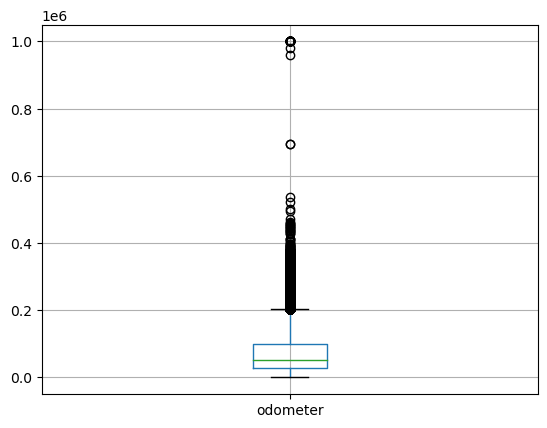

In [22]:
data_train.boxplot("odometer")

In [23]:
display(data_train[data_train["odometer"] >= 0.19 * (10 ** 6)].sort_values(by="odometer")) # чисто логически не может быть 2003	bmw	x5	unknown	suv	automatic	tx	2.7	999999.0	black	tan	3100	12 в хорошем состоянии

,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,sellingprice,car_age
104930,2000,toyota,4runner,unknown,suv,automatic,ca,4.5,190005.0,white,blue,3200,15
361164,2011,ford,escape,unknown,suv,automatic,fl,3.5,190005.0,red,beige,6800,4
133386,2003,honda,pilot,unknown,suv,automatic,ca,2.0,190005.0,white,black,2700,11
32103,2004,honda,accord,unknown,sedan,automatic,fl,2.5,190006.0,green,beige,3000,10
34648,2003,chevrolet,impala,unknown,sedan,automatic,pa,2.5,190007.0,white,beige,1600,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106234,2005,bmw,6 series,unknown,convertible,automatic,il,1.0,999999.0,silver,gray,1650,10
332344,2007,ford,taurus,unknown,sedan,automatic,ms,2.0,999999.0,white,tan,750,8
332467,2012,nissan,altima,unknown,sedan,automatic,oh,1.0,999999.0,white,black,800,3
22987,2005,nissan,quest,unknown,van,automatic,il,2.0,999999.0,green,gray,2600,9


In [24]:
for i in list(data_train.groupby("condition")["odometer"].mean().index):
    data_train.loc[(data_train["odometer"] >= 0.19 * (10 ** 6))&(data_train["condition"] == i), "odometer"] = data_train.groupby("condition")["odometer"].mean()[i]

In [25]:
data_train = data_train.dropna().reset_index(drop=True)

In [26]:
data_train.boxplot("sellingprice") # почему-то не показывается все время 2 график.

<Axes: >

In [27]:
cats = getfullitemsforOHE(data_train, CATIGORIES_COLUMNS)

In [28]:
ohe=OneHotEncoder(categories=cats, sparse=False, handle_unknown="ignore", drop='first')

X_train = ohe.fit_transform(data_train[CATIGORIES_COLUMNS])
ohe_train = pd.DataFrame(X_train,columns=ohe.get_feature_names_out(CATIGORIES_COLUMNS))

# X_test = ohe.fit_transform(data_test[CATIGORIES_COLUMNS])
# ohe_test = pd.DataFrame(X_test,columns=ohe.get_feature_names_out(CATIGORIES_COLUMNS))

C:\Users\Rog\Desktop\Programing\Python\envs\Kaggle\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


<div class="alert alert-success">
<b>Комментарий ревьюера ✔️:</b>
</div>

> Здорово, что использовал OnehotEncoder..


In [29]:
data_train = data_train.drop(CATIGORIES_COLUMNS, axis=1)
data_train = data_train.join(ohe_train)
# data_train = data_train.drop("year", axis=1)

# data_test = data_test.drop(CATIGORIES_COLUMNS, axis=1)
# data_test = data_test.join(ohe_test)

In [30]:
features = data_train.drop(["sellingprice"], axis=1)
target = data_train["sellingprice"]

In [31]:
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.15, random_state=RANDOM_STATE, shuffle=True)

<div class="alert alert-danger">
<b>Комментарий ревьюера ❌:</b>
</div>

Жалко, что не используешь кросс-валидацию и пайплайны!
    
При кросс-валидации и подборе гиперпараметров через GridSearchCV/RandomizedSearchCV на каждой итерации происходит разбиение на трейн и тест. Предобработка признаков (масштабирование, кодирование, векторизация) каждый раз должна проводиться независимо, иначе происходит утечка данных.
    
Вообще, при валидации мы должны максимально имитировать реальные условия, то есть обучаться на имеющихся данных, а трансформации и предсказания - на неизвестных. Так наша валидация будет более объективной.

---
        
- А вот здесь большой гайд как можно комбинировать разные этапы предобработки [Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html)

- Про кроссвалидацию можно почитать еще здесь https://academy.yandex.ru/handbook/ml/article/kross-validaciya

- Про пайплайны с тестированием набора различных моделей [Scikit-learn Pipeline Tutorial with Parameter Tuning and Cross-Validation](https://towardsdatascience.com/scikit-learn-pipeline-tutorial-with-parameter-tuning-and-cross-validation-e5b8280c01fb)

</div>

**Про catboost могу сказать так: я в данный момент времени стараюсь работать только на графической карте. В стандартном sklearn это не возможно, a cuda не разобрался, как запускать из под винды. По поводу кроссвалидации - слишком долго получается, большой объем данных на выходе (от 3.2 до 7)**

In [32]:
liner = LinearRegression()
liner.fit(features_train, target_train)

LinearRegression()

In [33]:
liner_predictons = liner.predict(features_test)
liner_mape = mean_absolute_percentage_error(target_test, liner_predictons)
print(f"Liner regression MAPE = {100*liner_mape:0.2f}")

Liner regression MAPE = 52.49


In [34]:
rfc = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=5)
rfc.fit(features_train, target_train)

RandomForestRegressor(max_depth=10, n_jobs=5, random_state=12345)

**В это время градиентный бустинг в максимальной комплектации только по глубине справляется на 30% быстее**

In [35]:
rfc_predictons = rfc.predict(features_test)
rfc_mape = mean_absolute_percentage_error(target_test, rfc_predictons)
print(f"Random Forest regression MAPE = {100*rfc_mape:0.2f}")

Random Forest regression MAPE = 40.38


In [38]:
cat = CatBoostRegressor(n_estimators=1000, depth=16, random_state=RANDOM_STATE, silent=True, task_type="GPU", devices="0:1")

In [39]:
cat.fit(features_train, target_train, eval_set=(features_test, target_test), plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [40]:
cat_predictions = cat.predict(features_test)
cat_mape = mean_absolute_percentage_error(target_test, cat_predictions)
print(f"CatBoost regression MAPE = {100*cat_mape:0.2f}")

CatBoost regression MAPE = 17.01


In [ ]:
# results = pd.DataFrame(pd.read_csv("./used-cars-price-prediction-19ds/test.csv")["vin"]).join(pd.DataFrame(cat.predict(data_test)))

In [ ]:
# results.columns = ["vin", "sellingprice"]

In [ ]:
# results.to_csv("result.csv", index=False)

**Вывод: получилось сделать модель со средним наименьшим mape (наименьшее mape было 16.7, но я не совсем помню, в каком именно коммите)**

<div class="alert alert-success">
<h2>Заключение ревьювера: </h2> 

Ты выполнил задачу исследования, но подошёл к процессу формально. Увы проект надо серьезно дорабатывать, усиливать анализ. Делать полноценный EDA, смотреть подробнее на признаки, там всё не так очевидно. Кросс-валидацию нужна, простые модели тоже нужны - надо идти от простого к сложному. Нужно уделить инжинирингу признаков, оценки важности признаков. Написать приложение тоже стоит...

❌ По оформлению работы: Нет итоговых выводов, структурности в проекте, результатов решения, почему именно эта модель, почему именно такая метрика, нет EDA, оценки важности признаков, приложения. 
    
⚠️ Обучение модели: Нет перехода от Baseline более простого решения к более сложному.
    
        
**Успехов в будущих проектах! Пусть ошибка не сбивает вас с толку, ошибки нужны для того чтобы учиться! Продолжайте в тоже духе!**      

**Хочу отметить по поводу анализа: к примеру есть пропуски в conditions и odometer, при этом оклоло 100-200 в conditions и  оdometer = 0. Однако всего nan после предобработки около 10 тысяч, соответственно легче убрать все пропуски, чем возиться с восстановлением, так как пропусков менее 1 процента от всех данных. Так же по котегориальным признакам - я предпочитаю убирать их анализ, так они занимают много места: сначала анализируюется, потом - удаляется. Извините, за 4 года в python привык не комментировать код, так как все комментарии занимают место, что мешает чтению.**